In [1]:
!pip install torch
!pip install roboflow
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.4/910.4 kB 23.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="nbHTEfCYA0IKVUgbEWcZ")
project = rf.workspace("hexaliz-pvs7r").project("apple-orange-yjnta")
version = project.version(9)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple-&-Orange--9 in yolov8:: 100%|██████████| 49/49 [00:00<00:00, 4750.50it/s]


In [4]:
# Load the YOLOv8 tiny model
model = YOLO('yolov8m.pt')  # Use the pretrained model as the base
# Train the model
model.train(
   data='/content/Apple-&-Orange--9/data.yaml',  # Path to data.yaml
   epochs=50,  # Number of epochs
   imgsz=640,  # Image size
   batch=16,  # Batch size
   workers=4,  # Number of data loading workers
   device=0,  # GPU index, 'cpu' for CPU
   name='Yolo_Aplle&orange'  # Experiment name
)
# Validate the model
metrics = model.val()
print("Validation Metrics:", metrics)
# Save the trained model explicitly
model_path = 'Yolo_Aplle&orange.pt'  # Path to save the trained model
model.save(model_path)
print(f"Model saved at {model_path}")

Ultralytics 8.3.64 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/Apple-&-Orange--9/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=4, project=None, name=Yolo_Aplle&orange, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

100%|██████████| 755k/755k [00:00<00:00, 22.0MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 95.8MB/s]


AMP: checks passed ✅


...

                   all          4          4      0.927      0.977      0.995      0.995
                 Apple          2          2      0.854          1      0.995      0.995
                Orange          2          2          1      0.954      0.995      0.995
Speed: 0.3ms preprocess, 9.9ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to runs/detect/Yolo_Aplle&orange
Ultralytics 8.3.64 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning Apple-&-Orange--9/test/labels... 20 images, 17 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<00:00, 734.04it/s]

val: New cache created: Apple-&-Orange--9/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.06it/s]


                   all         37         20      0.197        0.7      0.454       0.43
                 Apple         10         10      0.337        0.5      0.497      0.472
                Orange         10         10     0.0569        0.9      0.412      0.389
Speed: 0.4ms preprocess, 34.2ms inference, 0.0ms loss, 8.8ms postprocess per image
Results saved to runs/detect/Yolo_Aplle&orange2
Validation Metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c60e52bca10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.0170


0: 448x640 1 apple, 28.4ms
Speed: 2.5ms preprocess, 28.4ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


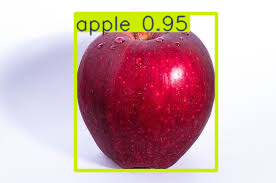

In [20]:
from ultralytics import YOLO

model = YOLO("/content/yolov8m.pt")

results = model(["/content/images (4).jpeg"])

for result in results:
    boxes = result.boxes
    masks = result.masks
    keypoints = result.keypoints
    probs = result.probs
    obb = result.obb
    result.show()
    result.save(filename="result.jpg")
